In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor

In [4]:
data = pd.read_csv("final_onshore_data_2017_2025.csv")
data["date"] = data['full_datetime'].str.rsplit('-', n=1).str[0]
data[['date', 'hour']] = data['correct_days'].str.rsplit('-', n=1, expand=True)
data['hour'] = data['hour'].astype(int) - 1
data['datetime'] = pd.to_datetime(data['date']) + pd.to_timedelta(data['hour'], unit='H')
data = data[data["date"] < "2025-01-01"]

data['month'] = data['datetime'].dt.to_period('M').astype(str)

start_date = pd.Timestamp('2017-01-01')
data['week_number'] = ((data['datetime'] - start_date).dt.days // 7) + 1

# Set 'datetime' as index for the dataset
data.set_index('datetime', inplace=True)

data["max_capacity"] = data["capacity"] / data["percentage"]
data["log_volume"] = np.log1p(data["volume"])
data["ratio_VC"] = data["volume"] / data["max_capacity"]


/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_563/1161484966.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  data['datetime'] = pd.to_datetime(data['date']) + pd.to_timedelta(data['hour'], unit='H')


In [6]:
# Creating lag features for time-series data

def create_lag_features(data, lag_steps=1):
    for i in range(1, lag_steps + 1):
        data[f'lag_{i}'] = data['volume'].shift(i)

    return data

# Applying lag feature creation to the dataset

lagged_data = create_lag_features(data, lag_steps=1)

In [8]:
data['rolling_mean_3'] = data['volume'].rolling(window=3).mean()

In [10]:
data.head()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,...,emissionfactor,correct_days,date,month,week_number,max_capacity,log_volume,ratio_VC,lag_1,rolling_mean_3
datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,20170101,0,207.708194,49.666667,49.666667,10234.526316,98.076923,2017-01-01-01,679334,679334,...,0,2017-01-01-01,2017-01-01,2017-01,1,861301.051331,13.428870,0.788730,NaN,NaN
2017-01-01 01:00:00,20170101,1,205.010321,50.000000,51.333333,10227.789474,98.153846,2017-01-01-02,677462,677462,...,0,2017-01-01-02,2017-01-01,2017-01,1,861299.514778,13.426110,0.786558,679334.0,NaN
2017-01-01 02:00:00,20170101,2,202.701006,51.666667,51.000000,10219.473684,98.230769,2017-01-01-03,653746,653746,...,0,2017-01-01-03,2017-01-01,2017-01,1,861297.084050,13.390476,0.759025,677462.0,670180.666667
2017-01-01 03:00:00,20170101,3,201.007553,52.333333,54.666667,10211.368421,98.038462,2017-01-01-04,705882,705882,...,0,2017-01-01-04,2017-01-01,2017-01,1,861302.267903,13.467205,0.819552,653746.0,679030.000000
2017-01-01 04:00:00,20170101,4,200.325015,52.666667,53.333333,10203.526316,97.461538,2017-01-01-05,716738,716738,...,0,2017-01-01-05,2017-01-01,2017-01,1,861300.347955,13.482467,0.832158,705882.0,692122.000000


In [12]:
len(data)

70128

In [14]:
data = data.dropna()

In [16]:
X = data.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "max_capacity"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y = data["volume"]
y_log = data["log_volume"]
X_train = X[X["date"] < "2024-12-25"]
X_test = X[X["date"] >= "2024-12-25"]

# Label
y_train = y[:X_train.shape[0]] #list slice: from beginning to end of X-train
y_test = y[X_train.shape[0]:] #list slice: from end of X-train to the end of the data
y_train_log = y_log[:X_train.shape[0]]
y_test_log = y_log[X_train.shape[0]:]

In [18]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)
print(y_train_log.shape)
print(y_test_log.shape)

(68362, 16)
(68362,)
(155,)
(155, 16)
(68362,)
(155,)


In [20]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "lag_1", "rolling_mean_3"]
X_train = X_train.loc[:, numeric_features]
X_test = X_test.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm = preprocessor.fit_transform(X_train)
X_test_norm = preprocessor.fit_transform(X_test)
X_train = pd.DataFrame(X_train_norm, columns=X_train.columns.values, index=X_train.index.values)
X_test = pd.DataFrame(X_test_norm, columns = X_test.columns.values, index=X_test.index.values)


In [22]:
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)

(68362, 8)
(68362,)
(155,)
(155, 8)


In [24]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB.fit(X_train, y_train) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model = cv_XGB.best_estimator_
XGB_pred = XGB_model.predict(X_test)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test, XGB_pred))


Mean cross-validated score of the best_estimator: 0.9553992867469787
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  795189668026.3821


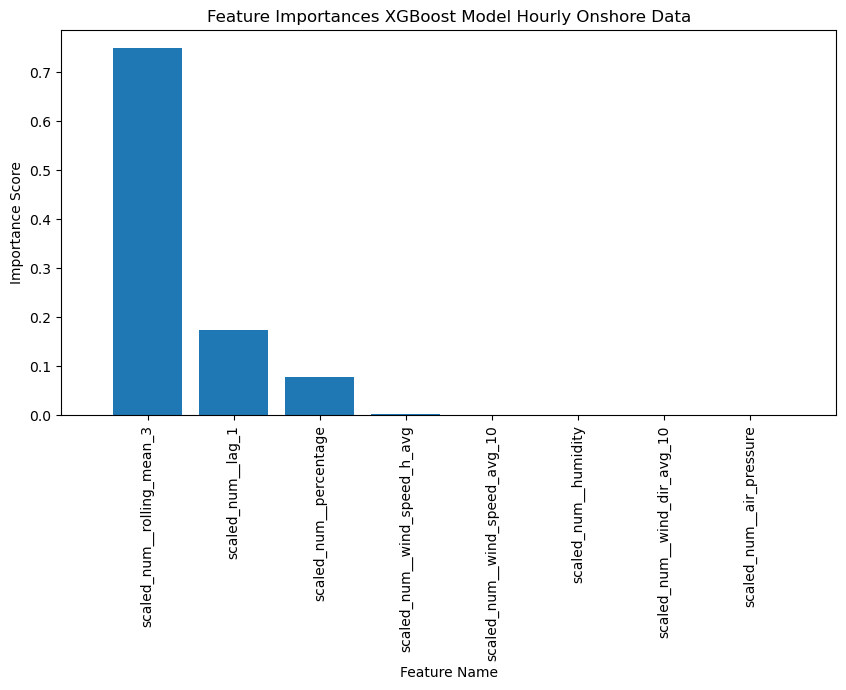

In [28]:
importances = XGB_model.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Hourly Onshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

# Logged version

In [376]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 42)
cv_XGB_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_log.fit(X_train, y_train_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_log = cv_XGB_log.best_estimator_
XGB_pred_log = XGB_model_log.predict(X_test)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_log, XGB_pred_log))


/Users/fmtetteroo/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mean cross-validated score of the best_estimator: 0.9728142725677115
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  1.141158835625942


In [378]:
x_axis_train = data["date"][:len(y_train_log)]
x_axis_test = data["date"][len(y_train_log):]
x_axis_train[0:5]
print(len(x_axis_train))
print(len(x_axis_test))

68362
155


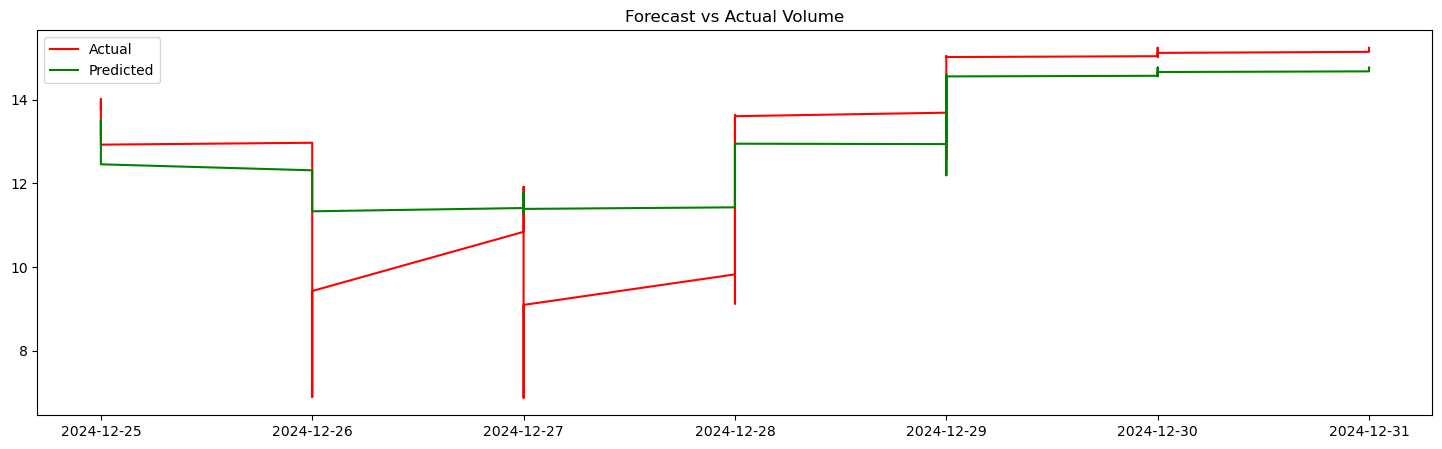

In [380]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test, y_test_log, label="Actual", color='red')
plt.plot(x_axis_test, XGB_pred_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Monthly

In [34]:
# Convert hourly data to monthly data
db_monthly = data.groupby('month').mean(numeric_only=True)
# Split into train and test set
train_db = db_monthly[db_monthly.index <= '2024-06']
test_db = db_monthly[db_monthly.index > '2024-06']

X_month = db_monthly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", "max_capacity"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_month_log = db_monthly["log_volume"]
y_month = db_monthly["volume"]

# Features
X_train_month = X_month[X_month.index <= '2024-06']
X_test_month = X_month[(X_month.index > '2024-06')]

# Label log
y_train_month_log = y_month_log[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month_log = y_month_log[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data

# Label
y_train_month = y_month[:X_train_month.shape[0]] #list slice: from beginning to end of X-train
y_test_month = y_month[X_train_month.shape[0]:] #list slice: from end of X-train to the end of the data


In [36]:
db_monthly.head()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,capacity,volume,percentage,emission,emissionfactor,week_number,max_capacity,log_volume,ratio_VC,lag_1,rolling_mean_3
month,,,,,,,,,,,,,,,,,,
2017-01,2.017012e+07,11.582026,188.675499,38.089348,38.133713,10223.051133,87.285459,423410.151213,423410.151213,0.491594,0.0,0.0,2.724679,861300.045483,12.357860,0.491594,423431.935806,423349.197337
2017-02,2.017021e+07,11.425758,167.038790,50.960181,51.001463,10153.188701,85.520033,590656.046970,590656.046970,0.685773,0.0,0.0,6.946970,861301.737837,13.078020,0.685773,590608.577273,590480.152525
2017-03,2.017032e+07,11.477490,187.599051,45.589916,45.676679,10155.119809,78.299799,419122.045020,419122.045020,0.486616,0.0,0.0,11.137790,861299.766603,12.627493,0.486616,419118.274216,419076.918145
2017-04,2.017042e+07,11.423831,245.535677,39.556065,39.780759,10205.904464,74.810594,414705.939668,414705.939668,0.481488,0.0,0.0,15.576169,861299.510125,12.597194,0.481488,413752.009050,413721.612368
2017-05,2.017052e+07,11.508310,169.377392,36.836916,36.938759,10170.260097,73.394675,328642.570637,328642.570637,0.381566,0.0,0.0,19.853186,861299.841886,12.305227,0.381566,329501.753463,329343.982918


In [38]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month.shape)
print(y_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)

(90, 11)
(6, 11)
(90,)
(6,)
(90,)
(6,)


In [40]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "rolling_mean_3", "lag_1"]
X_train_month = X_train_month.loc[:, numeric_features]
X_test_month = X_test_month.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_month = preprocessor.fit_transform(X_train_month)
X_test_norm_month = preprocessor.fit_transform(X_test_month)


In [42]:
#add feature names back 
X_train_month = pd.DataFrame(X_train_norm_month, columns=X_train_month.columns.values, index=X_train_month.index.values)

X_test_month = pd.DataFrame(X_test_norm_month, columns = X_test_month.columns.values, index=X_test_month.index.values)

X_train_month.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,rolling_mean_3,lag_1
2017-01,-0.053904,-0.552821,-0.565594,1.622990,1.080881,-0.228238,-0.740367,-0.740314
2017-02,-0.784915,1.106056,1.096533,0.035585,0.830427,0.683683,-0.456719,-0.456585
2017-03,-0.090272,0.413901,0.408730,0.079463,-0.193882,-0.251619,-0.747618,-0.747635
2017-04,1.867156,-0.363781,-0.352845,1.233386,-0.688884,-0.275698,-0.756706,-0.756743
2017-05,-0.705904,-0.714242,-0.719946,0.423479,-0.889755,-0.744965,-0.899909,-0.899731


In [44]:
print(X_train_month.shape)
print(X_test_month.shape)
print(y_train_month_log.shape)
print(y_test_month_log.shape)
print(y_train_month.shape)
print(y_test_month.shape)

(90, 8)
(6, 8)
(90,)
(6,)
(90,)
(6,)


In [46]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month.fit(X_train_month, y_train_month) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month = cv_XGB_month.best_estimator_
XGB_pred_month = XGB_model_month.predict(X_test_month)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month, XGB_pred_month))

Mean cross-validated score of the best_estimator: 0.7986547705790474
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  967648014991.044


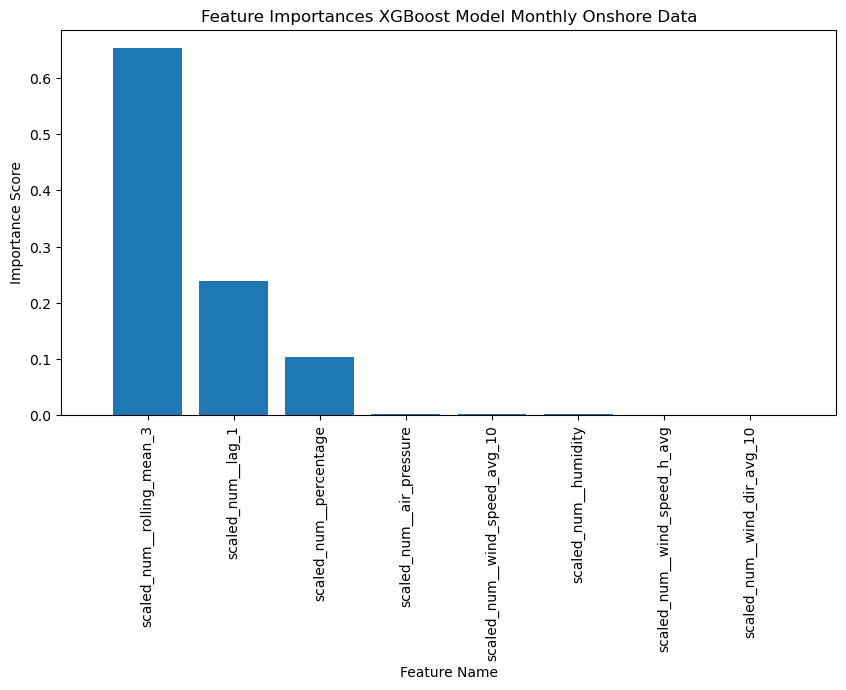

In [50]:
importances = XGB_model_month.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Monthly Onshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

In [52]:
x_axis_train_m = db_monthly["year_mon_day"][:len(y_train_month)]
x_axis_test_m = db_monthly["year_mon_day"][len(y_train_month):]
x_axis_train[0:5]
print(len(x_axis_train_m))
print(len(x_axis_test_m))
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_m, y_test_month, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

NameError: name 'x_axis_train' is not defined

In [108]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_month_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_month_log.fit(X_train_month, y_train_month_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_month_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_month_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_month_log = cv_XGB_month_log.best_estimator_
XGB_pred_month_log = XGB_model_month_log.predict(X_test_month)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_month_log, XGB_pred_month_log))


Mean cross-validated score of the best_estimator: 0.8180046103209344
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  0.9483597143317852


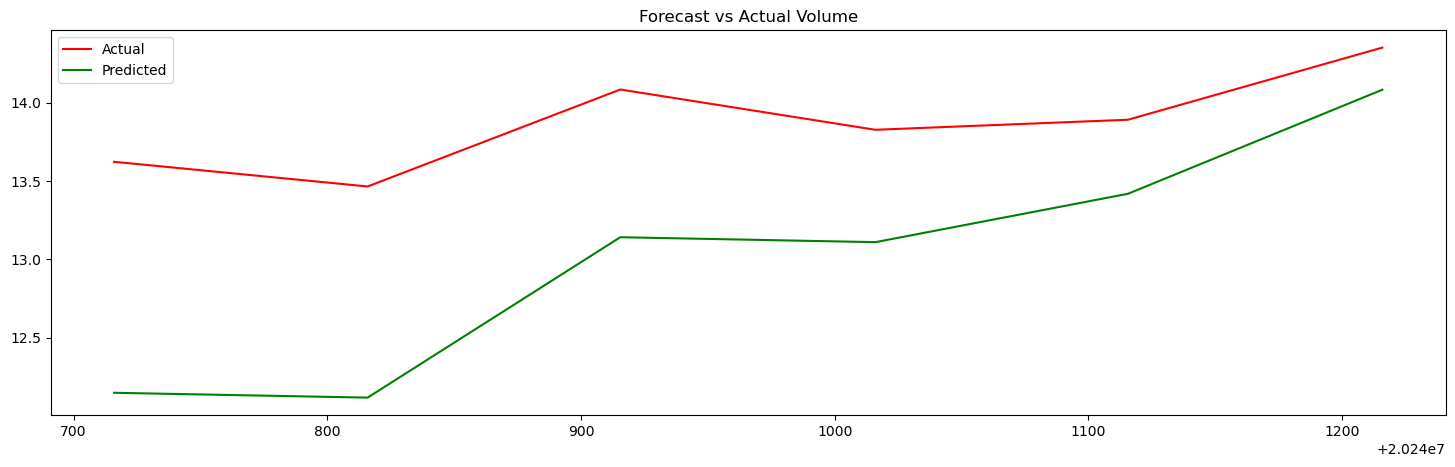

In [402]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_m, y_test_month_log, label="Actual", color='red')
plt.plot(x_axis_test_m, XGB_pred_month_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Weekly

In [54]:
# Convert hourly data to weekly data
db_weekly = data.groupby('week_number').mean(numeric_only=True)

X_week = db_weekly.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", "max_capacity"], #are always 0 and can be ignored
                      axis=1)

# our target variable
y_week = db_weekly["volume"]
y_week_log = db_weekly["log_volume"]

# Features
X_train_week = X_week[X_week.index <= 406]
X_test_week = X_week[(X_week.index > 406)]

# Label
y_train_week = y_week[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week = y_week[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

# Label Log
y_train_week_log = y_week_log[:X_train_week.shape[0]] #list slice: from beginning to end of X-train
y_test_week_log = y_week_log[X_train_week.shape[0]:] #list slice: from end of X-train to the end of the data

In [56]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 10)
(12, 10)
(406,)
(12,)
(406,)
(12,)


In [58]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "rolling_mean_3", "lag_1"]
X_train_week = X_train_week.loc[:, numeric_features]
X_test_week = X_test_week.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])


# Transform the data with the scaler
X_train_norm_week = preprocessor.fit_transform(X_train_week)
X_test_norm_week = preprocessor.fit_transform(X_test_week)

In [60]:
#add feature names back 
X_train_week = pd.DataFrame(X_train_norm_week, columns=X_train_week.columns.values, index=X_train_week.index.values)

X_test_week = pd.DataFrame(X_test_norm_week, columns = X_test_week.columns.values, index=X_test_week.index.values)

X_train_week.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,rolling_mean_3,lag_1
1,0.730062,0.227997,0.217437,1.466375,0.838731,0.604674,-0.417996,-0.417893
2,1.130925,1.063872,1.053260,-0.593932,1.080896,0.652094,-0.406841,-0.407101
3,-1.539462,-1.753182,-1.771233,2.298833,1.174521,-1.569585,-1.160990,-1.160143
4,-0.633880,-1.171063,-1.166310,1.170264,0.559978,-0.695180,-0.871216,-0.871354
5,-0.482708,-0.087900,-0.095107,-0.787338,1.056015,0.130236,-0.576731,-0.576640


In [62]:
print(X_train_week.shape)
print(X_test_week.shape)
print(y_train_week.shape)
print(y_test_week.shape)
print(y_train_week_log.shape)
print(y_test_week_log.shape)

(406, 8)
(12, 8)
(406,)
(12,)
(406,)
(12,)


In [64]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week.fit(X_train_week, y_train_week) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week = cv_XGB_week.best_estimator_
XGB_pred_week = XGB_model_week.predict(X_test_week)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week, XGB_pred_week))


Mean cross-validated score of the best_estimator: 0.9643851962324627
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1583993174859.2107


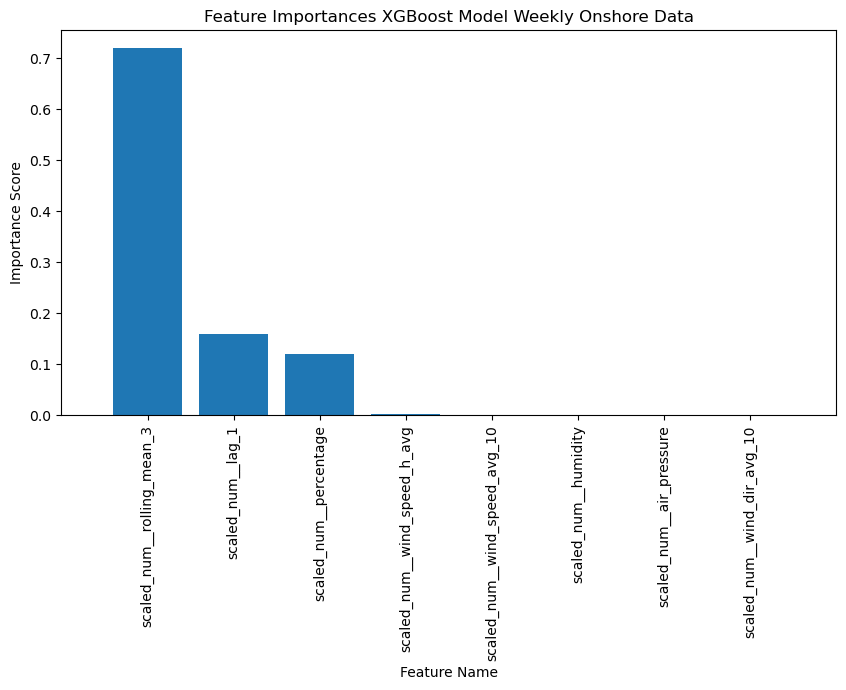

In [68]:
importances = XGB_model_week.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Weekly Onshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

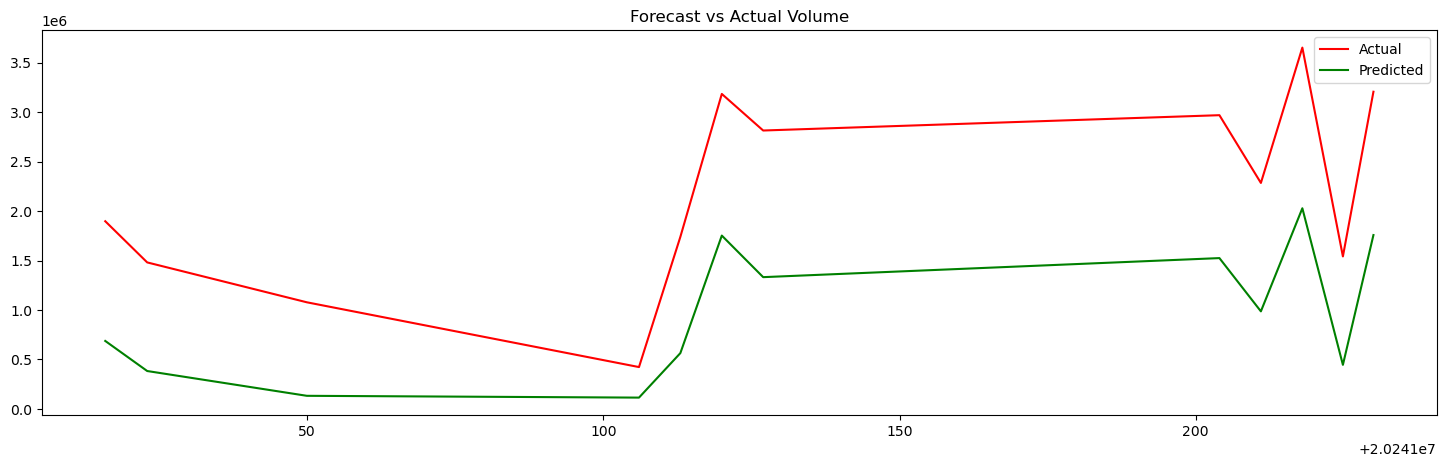

In [420]:
x_axis_train_w = db_weekly["year_mon_day"][:len(y_train_week)]
x_axis_test_w = db_weekly["year_mon_day"][len(y_train_week):]
print(len(x_axis_train_w))
print(len(x_axis_test_w))
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_w, y_test_week, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [422]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_week_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_week_log.fit(X_train_week, y_train_week_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_week_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_week_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_week_log = cv_XGB_week_log.best_estimator_
XGB_pred_week_log = XGB_model_week_log.predict(X_test_week)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_week_log, XGB_pred_week_log))


Mean cross-validated score of the best_estimator: 0.9106718977054171
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 100, 'subsample': 0.9}
Best XGB Classifier
Test Set MSE:  1.131995828548418


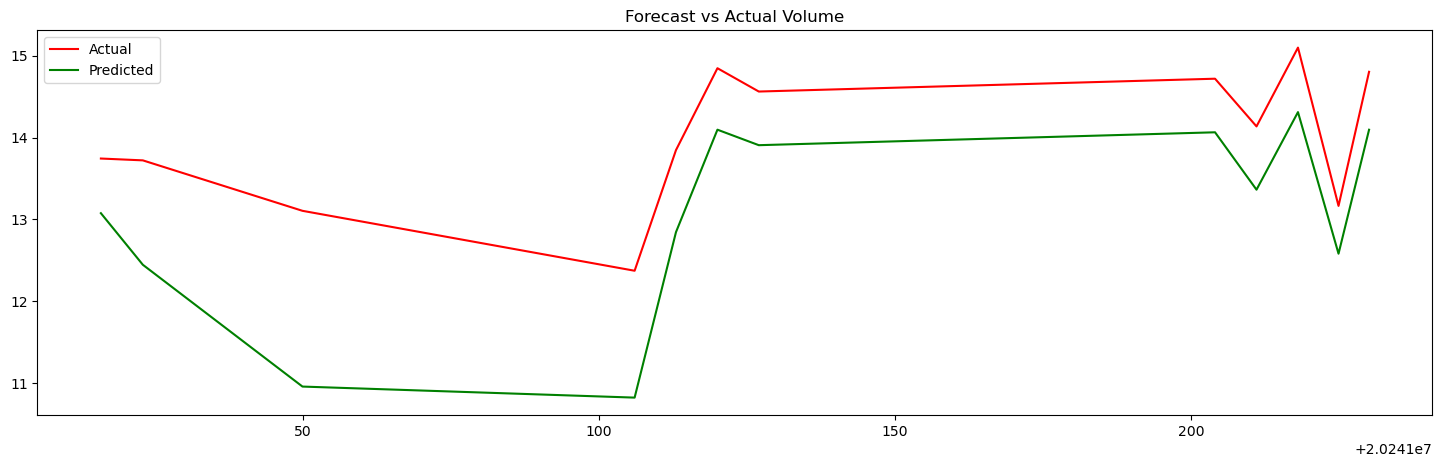

In [424]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_w, y_test_week_log, label="Actual", color='red')
plt.plot(x_axis_test_w, XGB_pred_week_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

# Daily

In [70]:
data['date2'] = pd.to_datetime(data['date'], format='ISO8601')
db_daily = data.groupby('date2').mean(numeric_only=True)
# Split into train and test set
db_daily.index = pd.to_datetime(db_daily.index)

X_day = db_daily.drop(["volume", "capacity",  #capacity & volume are the same
                    "emission", "emissionfactor", "log_volume", "ratio_VC", "max_capacity"], #are always 0 and can be ignored
                      axis=1)

#our targer variable
y_day = db_daily["volume"]
y_day_log = db_daily["log_volume"]

# Features
X_train_day = X_day[X_day.index <= '2024-11-01']
X_test_day = X_day[X_day.index > '2024-11-01']

# Label
y_train_day = y_day[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day = y_day[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data

# Label log
y_train_day_log = y_day_log[:X_train_day.shape[0]] #list slice: from beginning to end of X-train
y_test_day_log = y_day_log[X_train_day.shape[0]:] #list slice: from end of X-train to the end of the data


/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_563/1526157910.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['date2'] = pd.to_datetime(data['date'], format='ISO8601')


In [72]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 11)
(60, 11)
(2862,)
(60,)
(2862,)
(60,)


In [74]:
# subset dataframe to only contain the features we are interested in
numeric_features = ["wind_dir_avg_10", "wind_speed_h_avg", "wind_speed_avg_10", "air_pressure", "humidity", "percentage", "lag_1", "rolling_mean_3"]
X_train_day = X_train_day.loc[:, numeric_features]
X_test_day = X_test_day.loc[:, numeric_features]

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("scaled_num", StandardScaler(), numeric_features)
])

# Transform the data with the scaler
X_train_norm_day = preprocessor.fit_transform(X_train_day)
X_test_norm_day = preprocessor.fit_transform(X_test_day)

In [76]:
#add feature names back 
X_train_day = pd.DataFrame(X_train_norm_day, columns=X_train_day.columns.values, index=X_train_day.index.values)
X_test_day = pd.DataFrame(X_test_norm_day, columns = X_test_day.columns.values, index=X_test_day.index.values)
X_train_day.head()

,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,percentage,lag_1,rolling_mean_3
2017-01-01,0.287692,0.494598,0.492769,0.320097,1.615436,0.346135,-0.377692,-0.376094
2017-01-02,1.297249,-0.547346,-0.545713,0.811418,0.842117,1.001562,-0.117746,-0.119181
2017-01-03,0.818029,1.182943,1.222579,0.663662,0.861594,1.077148,-0.093552,-0.093816
2017-01-04,1.576213,1.388871,1.348700,0.204699,0.056216,1.222717,-0.031504,-0.031570
2017-01-05,-0.666379,-0.773872,-0.802904,1.760920,0.108561,-0.526584,-0.674082,-0.674212


In [78]:
print(X_train_day.shape)
print(X_test_day.shape)
print(y_train_day.shape)
print(y_test_day.shape)
print(y_train_day_log.shape)
print(y_test_day_log.shape)

(2862, 8)
(60, 8)
(2862,)
(60,)
(2862,)
(60,)


In [80]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day.fit(X_train_day, y_train_day) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day = cv_XGB_day.best_estimator_
XGB_pred_day = XGB_model_day.predict(X_test_day)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day, XGB_pred_day))

/Users/fmtetteroo/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mean cross-validated score of the best_estimator: 0.9743252381219476
Best parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 150, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  2105548241721.1553


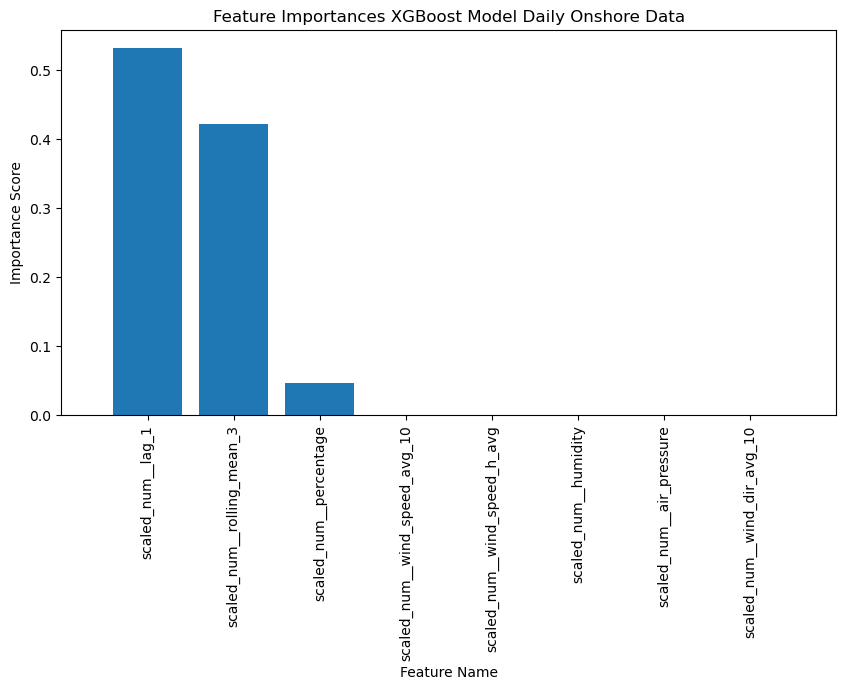

In [84]:
importances = XGB_model_day.feature_importances_

# Hint: We can get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Sort feature importances and feature names
indices = np.argsort(importances)[::-1]  # Sort in descending order
sorted_importances = importances[indices]
sorted_feature_names = feature_names[indices]  # Sort feature names accordingly

# Plot feature importances
plt.figure(figsize=(10, 5))
plt.title("Feature Importances XGBoost Model Daily Onshore Data")
plt.bar(range(len(importances)), sorted_importances, align="center")
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)  # Rotate for readability
plt.xlim([-1, len(importances)])
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

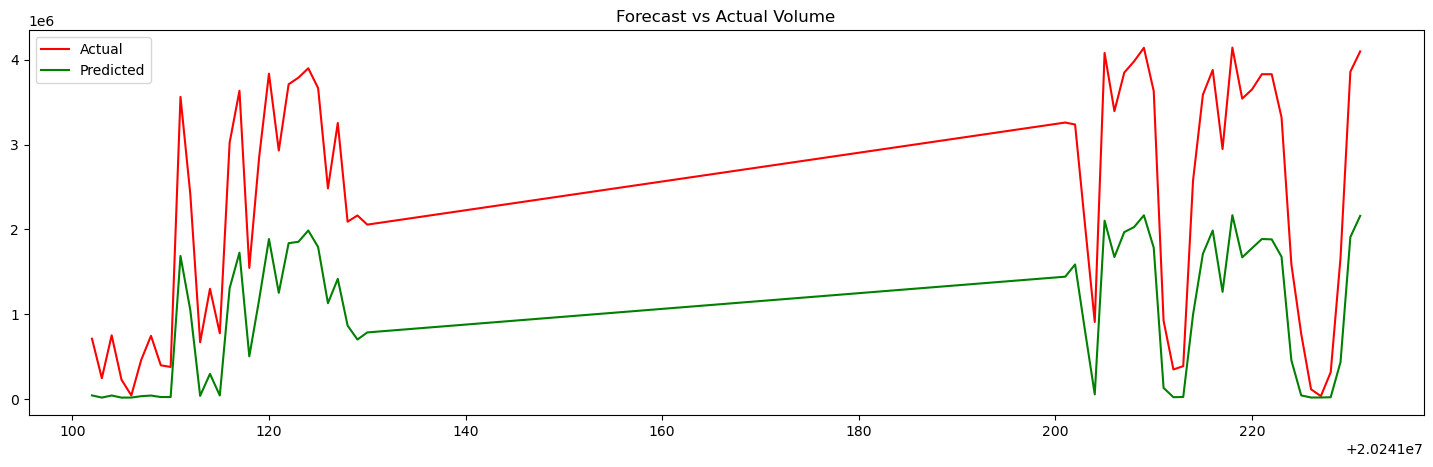

In [440]:
x_axis_train_d = db_daily["year_mon_day"][:len(y_train_day)]
x_axis_test_d = db_daily["year_mon_day"][len(y_train_day):]
print(len(x_axis_train_d))
print(len(x_axis_test_d))
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_d, y_test_day, label="Actual", color='red')
plt.plot(x_axis_test_d, XGB_pred_day, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [98]:
param_grid = {
    'max_depth': [5, 7],  
    'min_child_weight': [1, 2, 3],  
    'learning_rate': [0.01, 0.05],  
    'n_estimators': [50, 100, 150],  
    'subsample': [0.75, 0.9],  
    'colsample_bytree': [0.75, 0.9]
}

XGB = XGBRegressor(random_state = 15)
cv_XGB_day_log = GridSearchCV(estimator=XGB, param_grid=param_grid, cv=5) #Here we perform a grid search with 5-fold cross validation
cv_XGB_day_log.fit(X_train_day, y_train_day_log) # Fit the model to the training set - this will perform the grid search and find the model with the best hyper-parameters

# Mean cross-validated score of the best_estimator
print("Mean cross-validated score of the best_estimator:", cv_XGB_day_log.best_score_)

# Print the best parameters
print("Best parameters:", cv_XGB_day_log.best_params_)

# Refit the model with the best parameters on the entire training set
XGB_model_day_log = cv_XGB_day_log.best_estimator_
XGB_pred_day_log = XGB_model_day_log.predict(X_test_day)

#Calculating the accuracy
print("Best XGB Classifier")
print("Test Set MSE: ", mean_squared_error(y_test_day_log, XGB_pred_day_log))

Mean cross-validated score of the best_estimator: 0.9578294280296589
Best parameters: {'colsample_bytree': 0.75, 'learning_rate': 0.05, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.75}
Best XGB Classifier
Test Set MSE:  3.783552604831037


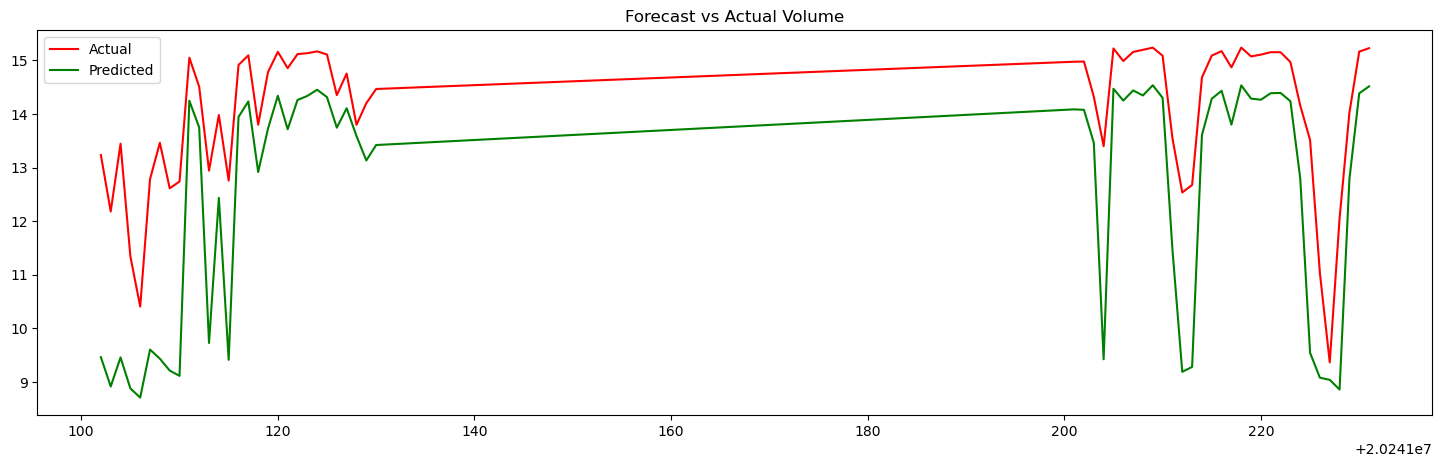

In [444]:
plt.figure(figsize=(18,5))
plt.plot(x_axis_test_d, y_test_day_log, label="Actual", color='red')
plt.plot(x_axis_test_d, XGB_pred_day_log, label="Predicted", color='green')
plt.legend()
plt.title("Forecast vs Actual Volume")
plt.show()

In [86]:
from sktime.forecasting.model_selection import temporal_train_test_split

# Onshore
on_df = pd.read_csv("final_onshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})
# Removing data from 2025
on_df = on_df[on_df['full_datetime'] < "2025-01-01-01"]
# Convert 'correct days' to datetype format for further processing
on_df[['date', 'hour']] = on_df['correct_days'].str.rsplit('-', n=1, expand=True)
on_df['hour'] = on_df['hour'].astype(int) - 1
on_df['datetime'] = pd.to_datetime(on_df['date']) + pd.to_timedelta(on_df['hour'], unit='h')
on_df = on_df.drop(['year_mon_day', 'hour', 'full_datetime', 'capacity', 'emission', 'emissionfactor', 'percentage', 'date', 'correct_days', "wind_speed_h_avg"], axis = 1)
# Set datetime as index
on_df = on_df.set_index('datetime')

# Monthly averages
on_df_m = on_df.resample('M').mean()
# Split data into target and exogenous variables
y_m = on_df_m['volume']
X_m = on_df_m.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_m, y_test_on_m, X_train_on_m, X_test_on_m = temporal_train_test_split(y_m, X_m, test_size=0.0625)

# Weekly averages
on_df_w = on_df.resample('W').mean()
# Remove last row for 2025-01-05
on_df_w = on_df_w.iloc[:-1]
# Split data into target and exogenous variables
y_w = on_df_w['volume']
X_w = on_df_w.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_w, y_test_on_w, X_train_on_w, X_test_on_w = temporal_train_test_split(y_w, X_w, test_size=0.0287)

# Daily averages
on_df_d = on_df.resample('D').mean()
# Split data into target and exogenous variables
y_d = on_df_d['volume']
X_d = on_df_d.drop('volume', axis=1)  # All exogenous variables
# Create train/test split
y_train_on_d, y_test_on_d, X_train_on_d, X_test_on_d = temporal_train_test_split(y_d, X_d, test_size=0.02053)

/var/folders/19/l03rx7hx7313wlqw4t3dy1wm0000gn/T/ipykernel_563/3998359679.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  on_df_m = on_df.resample('M').mean()


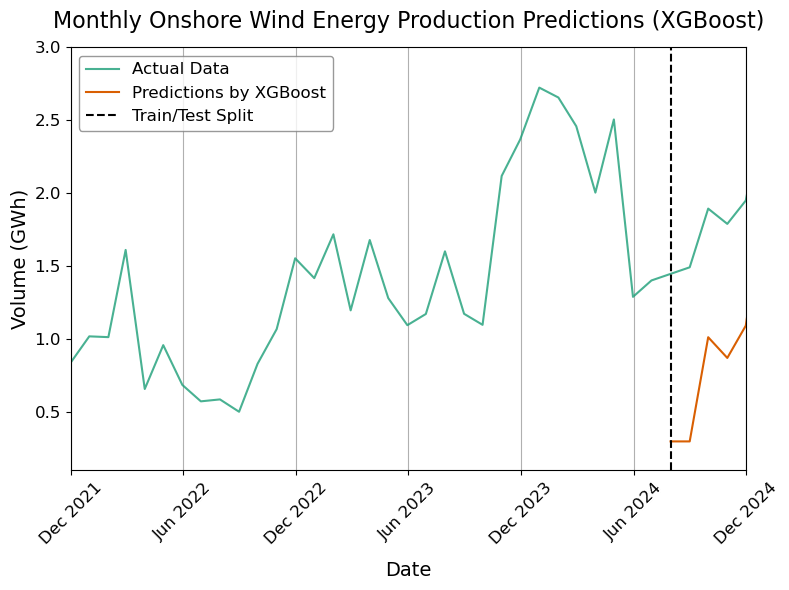

In [90]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# Function to convert to millions
def millions(x, pos):
    return f'{x * 1e-6:.1f}'

# ===== Monthly - onshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_m.index), on_df_m['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_m.index), XGB_pred_month, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_on_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Onshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
plt.ylim(top=3_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/on_m.png', dpi=300, bbox_inches='tight')
plt.show()

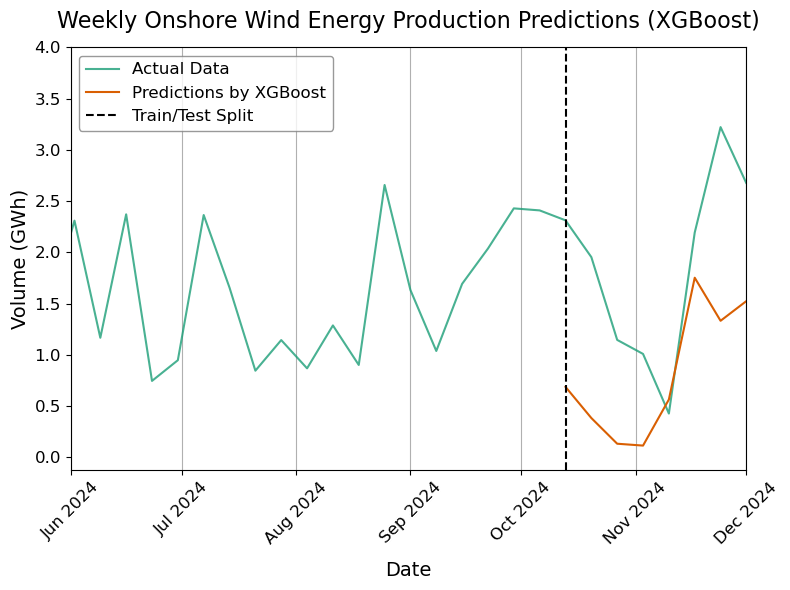

In [92]:
# ===== Weekly - onshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_w.index), on_df_w['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_w.index), XGB_pred_week, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_on_w.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Weekly Onshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-06'), pd.to_datetime('2024-12')) 
plt.ylim(top=4_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/on_w.png', dpi=300, bbox_inches='tight')
plt.show()

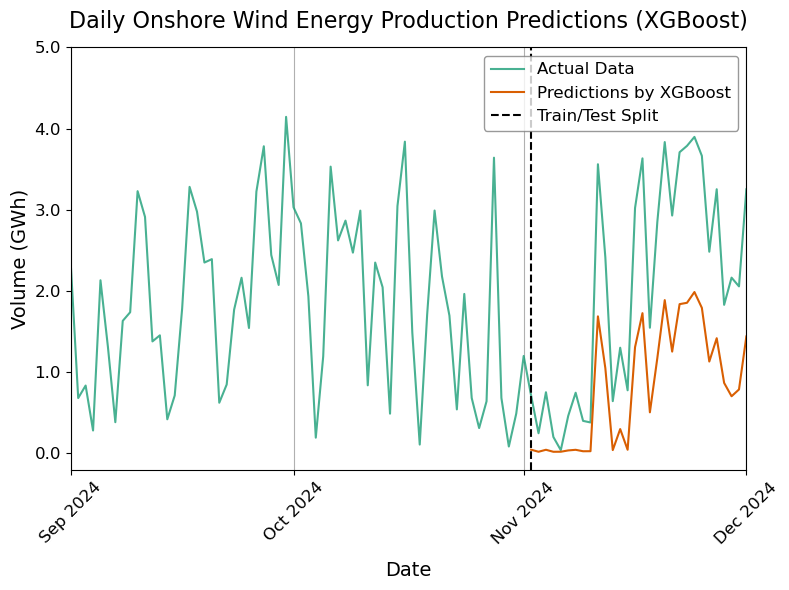

In [96]:
# ===== Daily - onshore =====
plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_d.index), on_df_d['volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_d.index), XGB_pred_day, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_on_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Onshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/on_d.png', dpi=300, bbox_inches='tight')
plt.show()

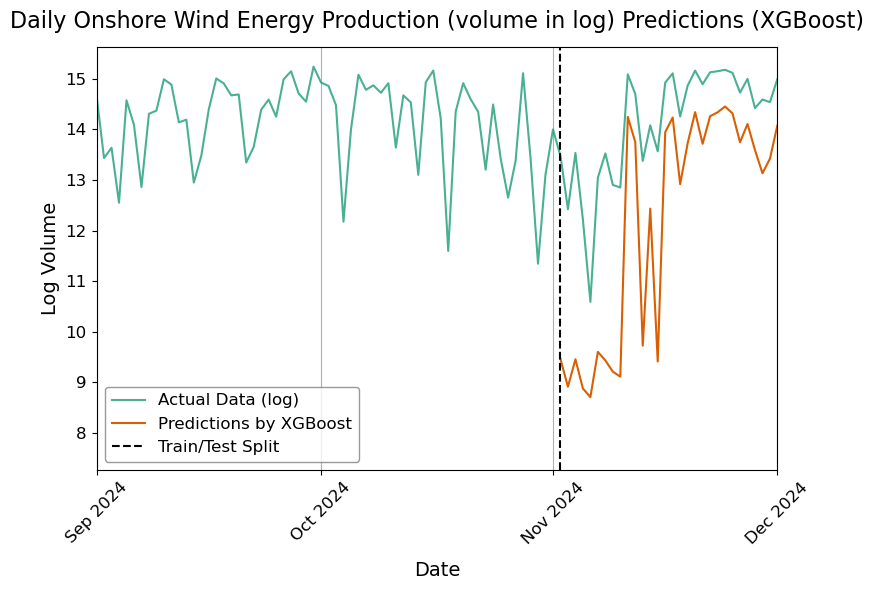

In [106]:
# ===== Daily - onshore log-variable =====
on_df_d["log_volume"] = np.log1p(on_df_d["volume"])

plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_d.index), on_df_d['log_volume'], label='Actual Data (log)', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_d.index), XGB_pred_day_log, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_on_d.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Daily Onshore Wind Energy Production (volume in log) Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
#plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Log Volume', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2024-09'), pd.to_datetime('2024-12')) 
#plt.ylim(top=5_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/on_d.png', dpi=300, bbox_inches='tight')
plt.show()

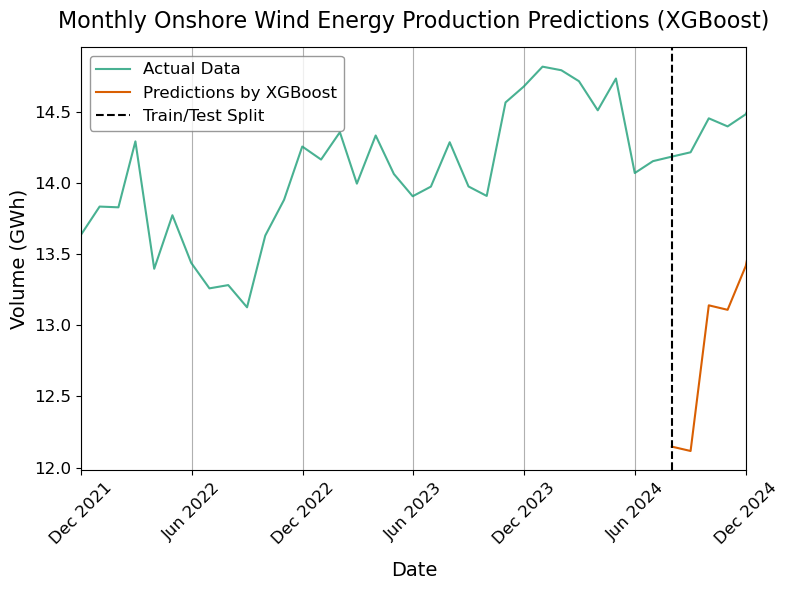

In [114]:
# ===== Monthly - onshore log-variable =====
on_df_m["log_volume"] = np.log1p(on_df_m["volume"])

plt.figure(figsize=(8, 6))
plt.plot(pd.to_datetime(on_df_m.index), on_df_m['log_volume'], label='Actual Data', color='#1b9e77', alpha = 0.8)
plt.plot(pd.to_datetime(y_test_on_m.index), XGB_pred_month_log, label='Predictions by XGBoost', color='#d95f02')
split_date = pd.to_datetime(y_test_on_m.index[0], format = '%Y-%m-%d')
plt.axvline(x=split_date, color='k', linestyle='--', label='Train/Test Split')
plt.title('Monthly Onshore Wind Energy Production Predictions (XGBoost)', pad = 14, size = 16)
plt.xlabel('Date', labelpad=10, size=14)
#plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.ylabel('Volume (GWh)', size=14)
plt.grid(axis = 'x')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xlim(pd.to_datetime('2021-12'), pd.to_datetime('2024-12')) 
#plt.ylim(top=3_000_000)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend(loc='best', fontsize=12, frameon=True, facecolor='white', edgecolor='grey', fancybox=True, framealpha = 0.8)
#plt.savefig('plots/on_m.png', dpi=300, bbox_inches='tight')
plt.show()